# Practice 14 — Dataloader for Image

표(table) 형태 데이터의 DataLoader 패턴을 **이미지 데이터** 로 확장합니다.

| 섹션 | 내용 |
|------|------|
| 1 | numpy 로 직접 표준화 + `TensorDataset` + `DataLoader` |
| 2 | Custom Dataset 클래스 + `transform` (ToTensor, Normalize) |
| 3 | `ImageFolder` + torchvision 내장 데이터셋 — 디스크 lazy 로딩 |
| 4 | 데이터 증강 (Augmentation) — 같은 idx, 매번 새로운 view |

이 노트북은 **데이터 준비만** 다룹니다. 모델 학습은 포함되지 않습니다.

In [1]:
# Windows + conda 환경에서 torch와 torchvision 동시 로드 시 OpenMP 충돌 회피
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)

torch: 2.6.0+cu124
torchvision: 0.21.0+cu124


---
# 1. TensorDataset + numpy 직접 처리

**CIFAR-10**: 32x32 컬러 사진, 10클래스 (plane, car, bird, cat, deer, dog, frog, horse, ship, truck).

표 데이터에서 했던 패턴을 그대로 적용합니다:
**numpy 로 X, y 준비 → 표준화 → `TensorDataset` → `DataLoader`**.

> **데이터 분할 안내**: CIFAR-10 은 `train (50000)` 과 `test (10000)` 로 **이미 미리 나뉘어** 배포됩니다. 이미지 표준 벤치마크는 보통 train/test 두 묶음만 제공합니다.
> 본 노트북에서는 그 test set 을 학습 모니터링용 **val** 로 사용합니다 (이름을 `val_set` 으로 명명).
> 실무에서는 train 의 일부를 별도 val 로 떼고, 진짜 test 는 학습이 모두 끝난 뒤 마지막에 한 번만 사용합니다.

먼저 `transform=None` 으로 받아 **numpy 원본** 그대로 살펴봅니다.

Train images: (50000, 32, 32, 3), dtype=uint8
Test  images: (10000, 32, 32, 3)
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


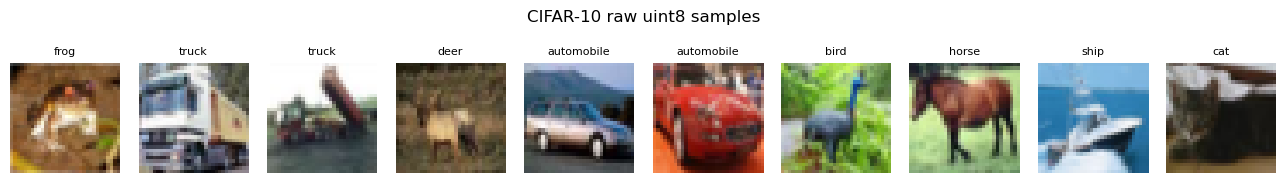

In [2]:
# transform 없이 받기 -> .data 가 (N, 32, 32, 3) uint8 numpy
cifar_train_raw = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True)
cifar_test_raw  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)
class_names = cifar_train_raw.classes

print(f'Train images: {cifar_train_raw.data.shape}, dtype={cifar_train_raw.data.dtype}')
print(f'Test  images: {cifar_test_raw.data.shape}')
print(f'Classes: {class_names}')

# 시연 속도를 위해 train 200장, val 50장만 사용 (학습이 목적이 아니라 DataLoader 동작 확인)
# 이 _raw 변수들은 다음 섹션들에서 그대로 재사용
X_train_raw = cifar_train_raw.data[:200]               # (200, 32, 32, 3) uint8
y_train_raw = np.array(cifar_train_raw.targets[:200])
X_val_raw   = cifar_test_raw.data[:50]
y_val_raw   = np.array(cifar_test_raw.targets[:50])

# 원본 uint8 샘플 10장 (정규화 전이라 imshow 그대로 OK)
fig, axes = plt.subplots(1, 10, figsize=(13, 1.7))
for i in range(10):
    axes[i].imshow(X_train_raw[i])
    axes[i].set_title(class_names[y_train_raw[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('CIFAR-10 raw uint8 samples', y=1.05)
plt.tight_layout(); plt.show()

### 표준화 + 텐서 변환 + DataLoader

표 데이터에서 했던 그대로:

- `[0, 1]` 스케일링 (uint8 → float, `/255`)
- 채널별 평균·표준편차 (`axis=(0, 1, 2)`): N·H·W 축으로 평균 → 결과 shape `(3,)`
  - 표 데이터에서는 `axis=0` (sample 축만) 으로 평균을 냈는데, 이미지는 sample 축 + 공간 축(H, W) 까지 합쳐 채널별 통계를 구합니다.
- train 통계를 train 과 val 둘 다에 적용
- PyTorch 는 `(N, C, H, W)` 순서를 기대 → `transpose` 로 채널 축을 앞으로

train_mean: [0.48704952 0.47413558 0.4340601 ]
train_std : [0.24321942 0.23946406 0.25190523]
Batch X shape: (8, 3, 32, 32)  (N, C, H, W)
Batch y shape: (8,)

First sample, channel 0, top-left 4x4 pixels:
[[-1.0512195  -1.3091967  -1.1963317  -0.90610707]
 [-1.7445335  -2.0025108  -1.7122864  -1.1802081 ]
 [-1.5994213  -1.7445335  -1.2124553  -0.66425335]
 [-1.4704326  -1.3898147  -0.59975904 -0.29341096]]


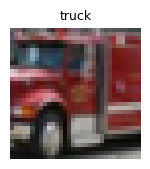

In [3]:
# 1) raw uint8 -> [0, 1] float32  (X_train_raw 는 그대로 둠)
X_train = X_train_raw.astype(np.float32) / 255.0
X_val   = X_val_raw.astype(np.float32)   / 255.0

# 2) 채널별 표준화 (train 통계만 사용)
train_mean = X_train.mean(axis=(0, 1, 2))   # (3,)
train_std  = X_train.std(axis=(0, 1, 2))    # (3,)
print(f'train_mean: {train_mean}')
print(f'train_std : {train_std}')

X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std

# ── 역표준화 헬퍼 ────────────────────────────────────────────────────────────
# 정규화된 텐서 (C, H, W) 를 matplotlib 이 표시할 수 있는 (H, W, C) float [0, 1] 로 되돌림.
# 이후 섹션들에서도 동일한 헬퍼를 재사용합니다.
def unnormalize(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()      # (C, H, W) -> (H, W, C)
    img = img * train_std + train_mean             # 채널별 broadcasting
    return np.clip(img, 0, 1)
# ────────────────────────────────────────────────────────────────────────────

# 3) numpy (N, H, W, C) -> torch (N, C, H, W)
X_train_t = torch.from_numpy(X_train.transpose(0, 3, 1, 2))
X_val_t   = torch.from_numpy(X_val.transpose(0, 3, 1, 2))
y_train_t = torch.LongTensor(y_train_raw)
y_val_t   = torch.LongTensor(y_val_raw)

# 4) TensorDataset + DataLoader
train_set = TensorDataset(X_train_t, y_train_t)
val_set   = TensorDataset(X_val_t,   y_val_t)

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)

batch_X, batch_y = next(iter(train_loader))
print(f'Batch X shape: {tuple(batch_X.shape)}  (N, C, H, W)')
print(f'Batch y shape: {tuple(batch_y.shape)}')

# 첫 샘플 첫 채널 좌상단 4x4 픽셀
print('\nFirst sample, channel 0, top-left 4x4 pixels:')
print(X_train_t[0, 0, :4, :4].numpy())

# 배치에서 한 샘플 시각화 — unnormalize 헬퍼 사용
plt.figure(figsize=(1.7, 1.7))
plt.imshow(unnormalize(batch_X[0]))
plt.title(class_names[batch_y[0].item()], fontsize=9)
plt.axis('off')
plt.show()

**여기까지의 한계**

- 텐서가 메모리에 **고정** 됩니다. 매 epoch 마다 같은 텐서가 반복됨 → 매번 다른 랜덤 변환(데이터 증강) 을 주는 것이 불가능합니다.
- 또한 CIFAR-10 처럼 데이터 전체가 메모리에 올라가는 작은 경우엔 OK 지만, 대용량 이미지(고해상도, 수십만 장) 는 디스크에서 **lazy load** 가 필요합니다.

두 한계 모두 다음 섹션의 **Custom Dataset** 으로 해결됩니다.

---
# 2. Custom Dataset 클래스 + transform

위 §1 의 작업(스케일링, 표준화, permute)을 매번 numpy 로 하면 코드가 길고 헷갈립니다.
`torchvision.transforms` 가 **정확히 그 작업** 을 한 줄로 대신해 줍니다.

| 메서드 | 역할 |
|--------|------|
| `__init__` | 데이터(X, y)와 transform 보관 |
| `__len__` | 전체 샘플 수 |
| `__getitem__(idx)` | idx번째 샘플 반환, 필요 시 transform 적용 |

`DataLoader` 가 매 배치마다 `__getitem__` 을 호출합니다 → transform 이 그 안에서 매번 호출됩니다.

아래 9줄짜리 템플릿을 그대로 외워두고 사용합니다.

In [4]:
class CIFAR10Dataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X                        # numpy uint8 (N, 32, 32, 3)
        self.y = y                        # numpy int   (N,)
        self.transform = transform

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        img = Image.fromarray(self.X[idx])     # numpy -> PIL (transform 입력 형식)
        if self.transform is not None:
            img = self.transform(img)
        return img, self.y[idx]

### Custom Dataset 으로 train_set + DataLoader — §1 과 같은 패턴

§1 의 흐름 (`train_set → DataLoader → 배치`) 을 그대로 따라갑니다. 다른 점은 `TensorDataset` 대신 우리가 정의한 `CIFAR10Dataset` 을 쓰고, §1 에서 numpy 로 손수 한 전처리(스케일링·표준화·permute)를 `transform` 인자에 묶어 전달한다는 것뿐.

- `ToTensor()`: PIL Image → `(C, H, W)` float 텐서, **자동으로 `/255` 까지 수행**
- `Normalize(mean, std)`: 채널별 표준화 (`train_mean`, `train_std` 그대로 재사용)

같은 `train_mean`, `train_std` 를 그대로 전달하면 §1 과 **수치적으로 동일한 결과** 가 나옵니다.

Batch X shape: (8, 3, 32, 32)  (N, C, H, W)
Batch y shape: (8,)

First sample, channel 0, top-left 4x4 pixels:
[[-1.0512195  -1.3091967  -1.1963317  -0.90610707]
 [-1.7445335  -2.0025108  -1.7122864  -1.1802081 ]
 [-1.5994213  -1.7445335  -1.2124553  -0.66425335]
 [-1.4704326  -1.3898147  -0.59975904 -0.29341096]]


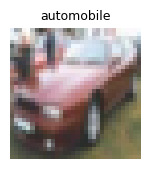

In [5]:
# §1 에서 계산한 train_mean, train_std 그대로 재사용
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(train_mean, train_std),
])

# §1 의 X_train_raw / X_val_raw 에 transform 부착해서 train_set, val_set
train_set = CIFAR10Dataset(X_train_raw, y_train_raw, transform=transform_basic)
val_set   = CIFAR10Dataset(X_val_raw,   y_val_raw,   transform=transform_basic)

# DataLoader → 배치 꺼내기 — §1 과 똑같은 흐름
train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)

batch_X, batch_y = next(iter(train_loader))
print(f'Batch X shape: {tuple(batch_X.shape)}  (N, C, H, W)')
print(f'Batch y shape: {tuple(batch_y.shape)}')

# 첫 샘플 첫 채널 좌상단 4x4 픽셀
print('\nFirst sample, channel 0, top-left 4x4 pixels:')
print(train_set[0][0][0, :4, :4].numpy())

# 배치에서 한 샘플 시각화 — unnormalize 헬퍼 사용 (§1 에서 정의)
plt.figure(figsize=(1.7, 1.7))
plt.imshow(unnormalize(batch_X[0]))
plt.title(class_names[batch_y[0].item()], fontsize=9)
plt.axis('off')
plt.show()

위 셀의 4x4 픽셀 출력을 §1 의 같은 출력과 위·아래로 비교해 보세요 — 동일한 값이 나옵니다. transform 두 줄이 §1 의 numpy 작업과 같은 결과를 만든다는 확인.

이제 정규화된 배치를 시각화하려면 **역표준화** 가 필요합니다 (그대로 `imshow` 하면 음수·양수 표준화 값이 들어가 색이 망가짐).

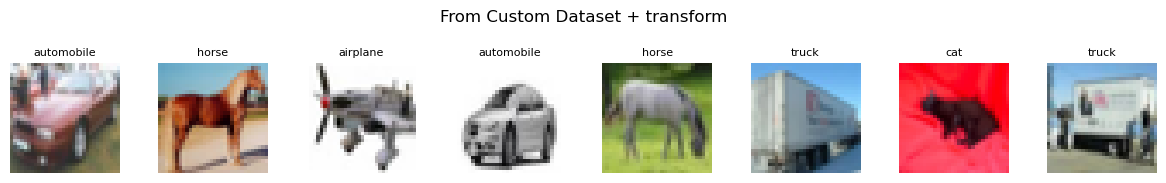

In [6]:
fig, axes = plt.subplots(1, 8, figsize=(12, 1.7))
for i in range(8):
    axes[i].imshow(unnormalize(batch_X[i]))
    axes[i].set_title(class_names[batch_y[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('From Custom Dataset + transform', y=1.05)
plt.tight_layout(); plt.show()

이 `__getitem__` 안에서는 무엇이든 할 수 있습니다. 다음 두 섹션은 그 자유를 두 방향으로 활용합니다.

- **§3**: 데이터를 메모리에 모두 올리지 않고 **디스크에서 한 장씩 lazy 로 읽기** → 대용량 데이터셋에서도 메모리 절약. `ImageFolder` 와 torchvision 내장 데이터셋이 이미 이렇게 동작합니다.
- **§4**: 매 호출마다 **다른 랜덤 변환** 을 적용 → 학습 시 epoch 마다 다른 입력 → 데이터 증강 (augmentation).

---
# 3. ImageFolder & torchvision 내장 — 디스크 lazy 로딩

§2 에서 만든 `CIFAR10Dataset` 과 **동작 원리는 같습니다** — `__getitem__` 이 호출될 때마다 한 샘플을 만들어 transform 을 적용해 돌려줍니다. 차이는 **데이터를 어디서 읽느냐**:

| 클래스 | 데이터 위치 | 메모리 |
|--------|------------|--------|
| §1 `TensorDataset` | 전체가 RAM 텐서 | 데이터 크기만큼 RAM 사용 (고정) |
| §2 `CIFAR10Dataset` (numpy 백킹) | 전체가 RAM numpy | 데이터 크기만큼 RAM 사용 (고정) |
| §3 `ImageFolder`, `torchvision.datasets.*` | **디스크에 파일** | `__getitem__` 호출 시 한 장씩 읽음 → batch 크기만큼만 RAM |

즉 §3 는 같은 transform API 를 그대로 쓰면서, 데이터셋이 RAM 에 안 들어가는 상황도 자연스럽게 처리합니다.

## 3.1 ImageFolder — 폴더 구조에서 자동 로드

디스크에 다음과 같이 정리되어 있으면 `ImageFolder(root, transform)` 한 줄로 끝납니다. 폴더명이 곧 클래스명.

```
ROOT/
├── train/
│   ├── plane/   img_000.png   img_001.png   ...
│   ├── car/     ...
│   └── bird/    ...
└── test/   (같은 구조)
```

> **자기 사진을 학습** 하고 싶다면 — `data/my_photos/<클래스명>/<파일.jpg>` 형태로 폴더만 만들면 같은 코드 한 줄로 DataLoader 완성.

여기서는 미리 준비한 **CIFAR5 ImageFolder** (5클래스 × train 100장 / test 50장 = 총 750장, ~2MB)를 GitHub Release 에서 다운로드해 사용합니다.

In [7]:
import urllib.request
import zipfile

ROOT = './data/cifar5_imagefolder'
URL  = 'https://github.com/jongmoonha/Ajou_ME_ML_Undergraduate/releases/download/data-v1/cifar5_imagefolder.zip'

if not os.path.exists(ROOT):
    os.makedirs('./data', exist_ok=True)
    print('Downloading CIFAR5 ImageFolder (~2MB)...')
    urllib.request.urlretrieve(URL, './data/cifar5_imagefolder.zip')
    with zipfile.ZipFile('./data/cifar5_imagefolder.zip') as zf:
        zf.extractall('./data/')
    os.remove('./data/cifar5_imagefolder.zip')
    print('Done.')

# 폴더 구조 확인
selected_class_names = sorted(os.listdir(f'{ROOT}/train'))
for split in ['train', 'test']:
    counts = {c: len(os.listdir(f'{ROOT}/{split}/{c}')) for c in selected_class_names}
    print(f'{split}: {counts}')

train: {'bird': 100, 'car': 100, 'cat': 100, 'deer': 100, 'plane': 100}
test: {'bird': 50, 'car': 50, 'cat': 50, 'deer': 50, 'plane': 50}


Samples      : 500
Classes      : ['bird', 'car', 'cat', 'deer', 'plane']
Class -> idx : {'bird': 0, 'car': 1, 'cat': 2, 'deer': 3, 'plane': 4}


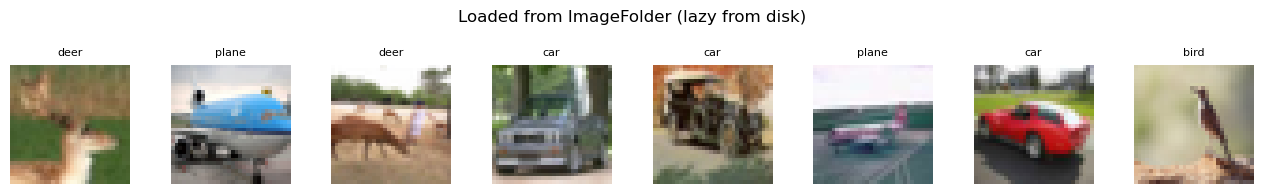

In [8]:
# ImageFolder 한 줄로 데이터셋 생성 — transform 인자는 §2 Custom Dataset 과 똑같이 사용
imgfolder_train = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/train',
    transform=transform_basic)

print(f'Samples      : {len(imgfolder_train)}')
print(f'Classes      : {imgfolder_train.classes}')
print(f'Class -> idx : {imgfolder_train.class_to_idx}')

# DataLoader 도 §2 와 동일 — Dataset 클래스가 바뀌었을 뿐
imgfolder_loader = DataLoader(imgfolder_train, batch_size=8, shuffle=True)
batch_X, batch_y = next(iter(imgfolder_loader))

fig, axes = plt.subplots(1, 8, figsize=(13, 1.8))
for i in range(8):
    axes[i].imshow(unnormalize(batch_X[i]))
    axes[i].set_title(imgfolder_train.classes[batch_y[i]], fontsize=8)
    axes[i].axis('off')
plt.suptitle('Loaded from ImageFolder (lazy from disk)', y=1.05)
plt.tight_layout(); plt.show()

## 3.2 torchvision 내장 데이터셋

표준 데이터셋 (`CIFAR10`, `MNIST`, `FashionMNIST` 등) 도 **같은 `transform` 인자**를 받습니다. Custom Dataset 을 만들 필요 없이 한 줄로 끝납니다.

여기서는 CIFAR-10 **literature 표준값** (50000장 전체에서 계산된 mean/std) 으로 `transform_basic` 의 mean/std 부분만 갈아끼웁니다. 잘 알려진 데이터셋은 이렇게 표준값이 공개되어 있어 직접 통계를 낼 필요가 없습니다.

In [9]:
# CIFAR-10 정규화 literature 표준값 (CIFAR-10 train 50000장에서 계산된 값, 잘 알려진 표준)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2440, 0.2620)

# transform_basic 을 데이터셋 표준값으로 재정의 (구조는 §2 와 동일, mean/std 만 교체)
transform_basic = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# torchvision 내장 CIFAR10 — Custom Dataset 도, ImageFolder 도 필요 없이 한 줄
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_basic)
cifar10_val   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_basic)

print(f'Train: {len(cifar10_train)}  /  Val (= CIFAR-10 test): {len(cifar10_val)}')

# DataLoader 흐름은 §1, §2 와 완전 동일
cifar10_loader = DataLoader(cifar10_train, batch_size=8, shuffle=True)
batch_X, batch_y = next(iter(cifar10_loader))
print(f'Batch X shape: {tuple(batch_X.shape)}')

Train: 50000  /  Val (= CIFAR-10 test): 10000
Batch X shape: (8, 3, 32, 32)


---
# 4. 데이터 증강 (Data Augmentation) — 같은 idx, 매번 새로운 view

지금까지의 `transform_basic` 은 매번 같은 출력을 줬습니다 (`ToTensor`, `Normalize` 는 결정론적). `transform` 의 진짜 강점은 **매 `__getitem__` 호출마다 다른 랜덤 변환을 lazy 하게 적용** 할 수 있다는 점입니다.

학습 시 매 epoch 마다 입력에 **랜덤 변환** 을 적용 → 사실상 데이터 양이 늘어나는 효과 → 과적합 억제.

**CIFAR-10 표준 조합:**
- `RandomCrop(32, padding=4)` : 가장자리 0 패딩 후 랜덤 위치에서 32x32 자르기
- `RandomHorizontalFlip(p=0.5)` : 50% 확률로 좌우 반전 (자연 객체는 좌우 대칭)

> augmentation 은 **train 에만 적용**, val/test 에는 적용 X (평가는 결정론적이어야 함).

## 4.1 §3 의 ImageFolder 에 augmentation 끼우기

§3 에서 만든 ImageFolder 를 **transform 만 갈아끼워** 다시 정의합니다. Dataset 클래스도, 파일도 그대로 — `transform` 인자 한 줄만 바뀜.

같은 인덱스 (`imgfolder_train_aug[0]`) 를 반복 호출하면 매번 다른 결과가 나오는 것을 확인합니다.

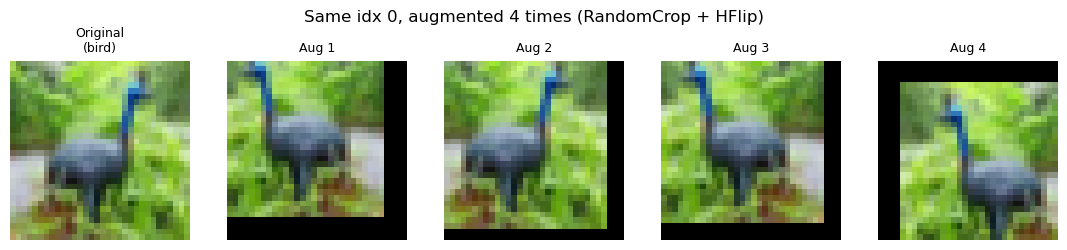

In [10]:
transform_train_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(train_mean, train_std),
])

# §3 ImageFolder 를 transform 만 바꿔서 다시 정의
imgfolder_train_aug = torchvision.datasets.ImageFolder(
    root=f'{ROOT}/train',
    transform=transform_train_aug)

# 같은 idx (0) 를 4번 호출 — 매번 다른 변환 적용
torch.manual_seed(0)
img_orig, label_orig = imgfolder_train[0]   # augmentation 없음 (transform_basic)

fig, axes = plt.subplots(1, 5, figsize=(11, 2.5))
axes[0].imshow(unnormalize(img_orig))
axes[0].set_title(f'Original\n({imgfolder_train.classes[label_orig]})', fontsize=9)
axes[0].axis('off')
for i in range(4):
    img_i, _ = imgfolder_train_aug[0]       # 호출할 때마다 매번 다른 변환
    axes[i+1].imshow(unnormalize(img_i))
    axes[i+1].set_title(f'Aug {i+1}', fontsize=9)
    axes[i+1].axis('off')
plt.suptitle('Same idx 0, augmented 4 times (RandomCrop + HFlip)')
plt.tight_layout(); plt.show()

## 4.2 `next(iter(train_loader))` 도 매번 새로운 batch

DataLoader 는 내부적으로 `__getitem__` 을 호출해 배치를 모읍니다. 따라서 augmentation transform 이 끼워진 loader 는 **호출할 때마다 다른 batch** 를 돌려줍니다.

비교를 명확하게 보기 위해 여기서는 **`shuffle=False`** 로 두 번 호출합니다 → **같은 인덱스의 같은 이미지**가 매번 다른 augmentation 으로 나오는 것을 한눈에 비교. 실제 학습 시에는 보통 `shuffle=True` 를 사용합니다.

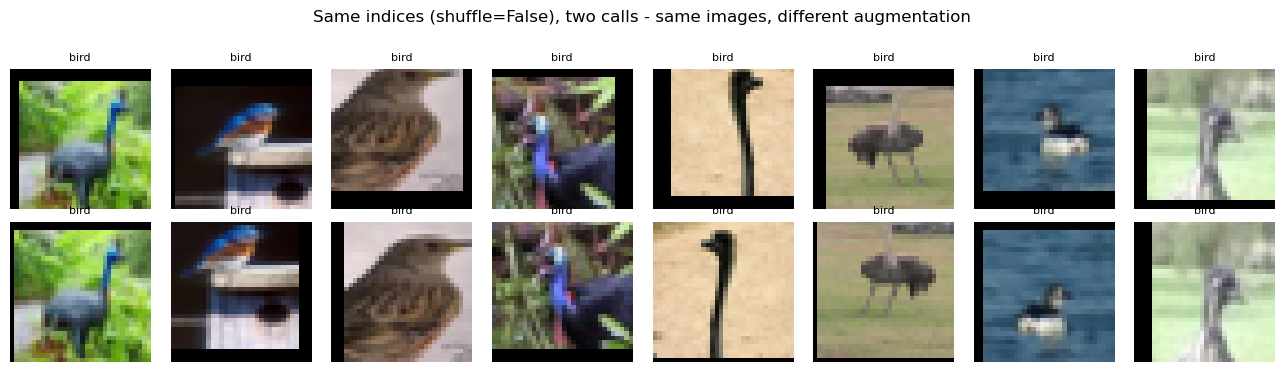

In [11]:
# 비교를 명확하게 보려고 shuffle=False — 두 번 호출해도 같은 인덱스의 이미지가 나옴 (transform 만 매번 다름)
train_loader_aug = DataLoader(imgfolder_train_aug, batch_size=8, shuffle=False)

batch1_X, batch1_y = next(iter(train_loader_aug))
batch2_X, batch2_y = next(iter(train_loader_aug))   # 또 호출 -> 같은 인덱스, 다른 aug

fig, axes = plt.subplots(2, 8, figsize=(13, 3.6))
for i in range(8):
    axes[0, i].imshow(unnormalize(batch1_X[i]))
    axes[0, i].set_title(imgfolder_train.classes[batch1_y[i]], fontsize=8)
    axes[0, i].axis('off')
    axes[1, i].imshow(unnormalize(batch2_X[i]))
    axes[1, i].set_title(imgfolder_train.classes[batch2_y[i]], fontsize=8)
    axes[1, i].axis('off')
plt.suptitle('Same indices (shuffle=False), two calls - same images, different augmentation', y=1.02)
plt.tight_layout(); plt.show()

## 4.3 실제 학습용 DataLoader 구성

- `train_loader` 에는 **augmentation 포함** transform
- `val_loader`   에는 **basic transform 만** (augmentation X — 평가는 결정론적)

데이터 출처는 ImageFolder 든 torchvision 내장이든 Custom Dataset 이든 무엇이든 OK — transform 인자만 위 두 가지로 나눠 끼우면 됩니다.

In [12]:
# train 은 aug, val 은 basic
train_set_final = torchvision.datasets.ImageFolder(root=f'{ROOT}/train', transform=transform_train_aug)
val_set_final   = torchvision.datasets.ImageFolder(root=f'{ROOT}/test',  transform=transform_basic)

train_loader_final = DataLoader(train_set_final, batch_size=8, shuffle=True)
val_loader_final   = DataLoader(val_set_final,   batch_size=8, shuffle=False)

X, y = next(iter(train_loader_final));  print(f'Train batch: {tuple(X.shape)}  (aug 적용)')
X, y = next(iter(val_loader_final));    print(f'Val   batch: {tuple(X.shape)}  (aug 없음)')

Train batch: (8, 3, 32, 32)  (aug 적용)
Val   batch: (8, 3, 32, 32)  (aug 없음)


---
## 정리

| Dataset 클래스 | 데이터 위치 | 언제 사용 |
|----------------|------------|----------|
| `TensorDataset` | RAM 텐서 | 데이터가 메모리에 다 올라가고, 증강이 필요 없는 경우 |
| **Custom Dataset 클래스** | 자유 (numpy / 디스크 / 무엇이든) | 데이터 형식이 비표준이거나 직접 제어가 필요할 때 |
| **`ImageFolder`** | 디스크 (lazy) | 폴더 구조로 정리된 파일 — 사용자 사진 그대로 활용 |
| **torchvision 내장 데이터셋** | 디스크 (lazy) | 표준 벤치마크 (CIFAR-10, MNIST 등) |

네 방법 모두 **`transform` 인자 사용법이 동일** — `Compose([RandomCrop, HFlip, ToTensor, Normalize])` 형태로 전처리·증강 파이프라인을 묶어 전달합니다.

| 분할 | 적용 transform |
|------|---------------|
| train | augmentation + ToTensor + Normalize |
| val / test | ToTensor + Normalize (augmentation X) |

Dataset 을 바꾸든 transform 을 바꾸든 **DataLoader → `next(iter())` → batch** 흐름은 동일하다는 점이 핵심.